In [9]:
import numpy as np
import string
import glob
import os
import warnings
import tensorflow as tf
warnings.filterwarnings('ignore')
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add, RepeatVector, Reshape, concatenate
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer 
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tqdm import tqdm
os.environ['TQDM_DISABLE'] = '1'

In [ ]:
# Mapping image IDs to their descriptions

def load_doc(filename):
  with open(filename, 'r') as f:
    text = f.read()
  return text

filename='Flickr8k.token.txt'
doc=load_doc(filename)

desc = {}
for line in doc.strip().split('\n'):
  tokens = line.split('\t')
  img_id, img_desc = tokens[0], tokens[1]
  img_id = img_id.split('#')[0]
  img_desc = img_desc.lower().translate(str.maketrans('', '', string.punctuation))
  if img_id not in desc:
    desc[img_id] = []
  desc[img_id].append('startseq'+img_desc+'endseq')

print(f"Loaded {len(desc)} image descriptions.")

Loaded 8092 image descriptions.


In [ ]:
# Extracting features from images using InceptionV3 pre-trained model

model = InceptionV3(weights='imagenet')
model = Model(model.input, model.layers[-2].output)

features = {}
images = glob.glob('Flicker8k_Dataset/*.jpg')

for img_path in tqdm(images, disable=False):
  img_id = os.path.basename(img_path).split('.')[0]
  img = image.load_img(img_path, target_size=(299, 299))
  img = image.img_to_array(img)
  img = np.expand_dims(img, axis=0)
  img = preprocess_input(img)
  feature = model.predict(img, verbose=0)
  features[img_id] = feature

print(f"Extracted features for {len(features)} images.")

I0000 00:00:1752061280.033702    2760 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
  0%|          | 0/8091 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1752061284.711145    5597 service.cc:152] XLA service 0x7ff9740541e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752061284.711196    5597 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-07-09 17:11:24.827137: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752061285.858997    5597 cuda_dnn.cc:529] Loaded cuDNN version 90800
2025-07-09 17:11:27.736117: W external/local_xla/

Extracted features for 8091 images.


In [ ]:
# Preparing the tokenizer and vocabulary size

descs = []
for key in desc:
  [descs.append(d) for d in desc[key]]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(descs)
vocab_size = len(tokenizer.word_index) + 1
maxLen = max(len(d.split()) for d in descs)
print(f"Vocabulary Size: {vocab_size}")
print(f"Max Caption Length: {maxLen}")

Vocabulary Size: 10279
Max Caption Length: 37


In [ ]:
# Function to create a TensorFlow dataset from the image descriptions and features

def create_tf_dataset(desc, features, tokenizer, maxLen, vocab_size, batch_size):
    def data_generator():
        while True:
            for key, value in desc.items():
                if key in features:
                    feature = features[key][0]
                    for d in value:
                        seq = tokenizer.texts_to_sequences([d])[0]
                        for i in range(1, len(seq)):
                            in_seq, out_seq = seq[:i], seq[i]
                            in_seq = pad_sequences([in_seq], maxlen=maxLen)[0]
                            out_seq_onehot = to_categorical(out_seq, num_classes=vocab_size)
                            yield (feature, in_seq), out_seq_onehot
    feature_dim = features[list(features.keys())[0]][0].shape[0]
    output_signature = (
        (
            tf.TensorSpec(shape=(feature_dim,), dtype=tf.float32),
            tf.TensorSpec(shape=(maxLen,), dtype=tf.int32)
        ),
        tf.TensorSpec(shape=(vocab_size,), dtype=tf.float32)
    )
    dataset = tf.data.Dataset.from_generator(data_generator, output_signature=output_signature)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [12]:
# Architecture taken from the paper "Show and Tell: A Neural Image Caption Generator" -> https://arxiv.org/pdf/1411.4555.pdf

inputs1 = Input(shape=(2048,))
feature1 = Dense(256, activation='relu')(inputs1)
feature1_reshaped = Reshape((1, 256), input_shape=(256,))(feature1)

inputs2 = Input(shape=(maxLen,))
emb1 = Embedding(vocab_size, 256, mask_zero = False)(inputs2)
merged = concatenate([feature1_reshaped, emb1], axis=1)
emb2 = LSTM(256)(merged)
emb3 = Dropout(0.5)(emb2)
combined = add([emb3, feature1])
x = Dense(256, activation='relu')(combined)
x = Dropout(0.5)(x)
outputs = Dense(vocab_size, activation='softmax')(x)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 256)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 37, 256)   │  2,631,424 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 38, 256)   │          0 │ reshape_2[0][0],  │
│ (Concatenate)       │                   │            │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    525,312 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dropout_2[0][0],  │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10279)     │  2,641,703 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,388,775 (24.37 MB)

 Trainable params: 6,388,775 (24.37 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
batch_size = 32
epochs = 30

def normalize_desc_keys(desc):
    normalized_desc = {}
    for key, value in desc.items():
        new_key = key.replace('.jpg', '')
        normalized_desc[new_key] = value
    return normalized_desc

desc_normalized = normalize_desc_keys(desc)

common_keys = set(desc_normalized.keys()).intersection(set(features.keys()))
filtered_desc = {key: desc_normalized[key] for key in common_keys}

def calculate_steps(desc, batch_size):
    total_seq = 0
    for key, value in desc.items():
        for d in value:
            seq_len = len(tokenizer.texts_to_sequences([d])[0])
            total_seq += max(1, seq_len - 1)
    return total_seq // batch_size

steps = calculate_steps(filtered_desc, batch_size)
print(f"Total Steps per Epoch: {steps}")
print(f"Number of images: {len(filtered_desc)}")
print(f"Total sequences: {steps * batch_size}")

callbacks = [
    ModelCheckpoint('model.h5', save_best_only=True, monitor='loss'),
    EarlyStopping(patience=5, monitor='loss', restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7)
]

dataset = create_tf_dataset(filtered_desc, features, tokenizer, maxLen, vocab_size, batch_size)

history = model.fit(
    dataset,
    epochs=epochs,
    steps_per_epoch=steps,
    callbacks=callbacks,
    verbose=1
)

Total Steps per Epoch: 13520
Number of images: 8091
Total sequences: 432640
Epoch 1/30
13519/13520 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2147 - loss: 5.0295

13520/13520 ━━━━━━━━━━━━━━━━━━━━ 336s 25ms/step - accuracy: 0.2147 - loss: 5.0294 - learning_rate: 0.0010
Epoch 2/30
13518/13520 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2781 - loss: 4.1908

13520/13520 ━━━━━━━━━━━━━━━━━━━━ 346s 26ms/step - accuracy: 0.2781 - loss: 4.1908 - learning_rate: 0.0010
Epoch 3/30
13518/13520 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2881 - loss: 4.0167

13520/13520 ━━━━━━━━━━━━━━━━━━━━ 338s 25ms/step - accuracy: 0.2881 - loss: 4.0167 - learning_rate: 0.0010
Epoch 4/30
13520/13520 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2950 - loss: 3.9248

13520/13520 ━━━━━━━━━━━━━━━━━━━━ 332s 25ms/step - accuracy: 0.2950 - loss: 3.9248 - learning_rate: 0.0010
Epoch 5/30
13519/13520 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2992 - loss: 3.8705

...

13520/13520 ━━━━━━━━━━━━━━━━━━━━ 342s 25ms/step - accuracy: 0.3155 - loss: 3.7110 - learning_rate: 0.0010
Epoch 17/30
13520/13520 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3167 - loss: 3.7057

13520/13520 ━━━━━━━━━━━━━━━━━━━━ 341s 25ms/step - accuracy: 0.3167 - loss: 3.7057 - learning_rate: 0.0010
Epoch 18/30
13519/13520 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3167 - loss: 3.7073

13520/13520 ━━━━━━━━━━━━━━━━━━━━ 344s 25ms/step - accuracy: 0.3167 - loss: 3.7073 - learning_rate: 0.0010
Epoch 19/30
13520/13520 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3162 - loss: 3.7062

13520/13520 ━━━━━━━━━━━━━━━━━━━━ 368s 27ms/step - accuracy: 0.3162 - loss: 3.7062 - learning_rate: 0.0010
Epoch 20/30
13519/13520 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3174 - loss: 3.7015

13520/13520 ━━━━━━━━━━━━━━━━━━━━ 513s 38ms/step - accuracy: 0.3174 - loss: 3.7015 - learning_rate: 0.0010
Epoch 21/30
13520/13520 ━━━━━━━━━━━━━━━━━━━━ 542s 40ms/step - accuracy: 0.3178 - loss: 3.7072 - learning_rate: 0.0010
Epoch 22/30
13520/13520 ━━━━━━━━━━━━━━━━━━━━ 569s 42ms/step - accuracy: 0.3191 - loss: 3.6994 - learning_rate: 0.0010
Epoch 23/30
13520/13520 ━━━━━━━━━━━━━━━━━━━━ 456s 34ms/step - accuracy: 0.3191 - loss: 3.7035 - learning_rate: 0.0010
Epoch 24/30
13520/13520 ━━━━━━━━━━━━━━━━━━━━ 337s 25ms/step - accuracy: 0.3188 - loss: 3.7036 - learning_rate: 0.0010
Epoch 25/30
13520/13520 ━━━━━━━━━━━━━━━━━━━━ 343s 25ms/step - accuracy: 0.3189 - loss: 3.7038 - learning_rate: 0.0010


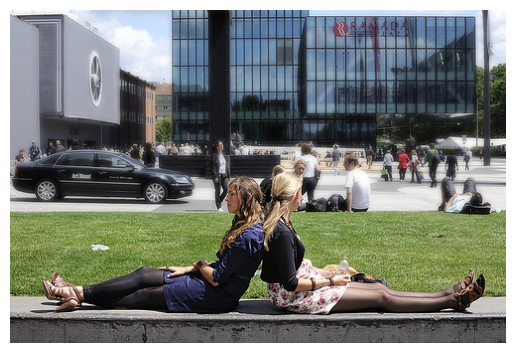

startseq and people are standing on a bench endseq


In [ ]:
def generate_desc(model, tokenizer, photo, max_length):
    in_text = 'startseq'
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = None
        for w, index in tokenizer.word_index.items():
            if index == yhat:
                word = w
                break
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text

keys = list(features.keys())
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image_file_path = 'Flicker8k_Dataset/' + keys[19] + '.jpg'
img = mpimg.imread(image_file_path)
plt.imshow(img)
plt.axis('off')
plt.show()
photo = features[keys[19]]
print(generate_desc(model, tokenizer, photo, maxLen))


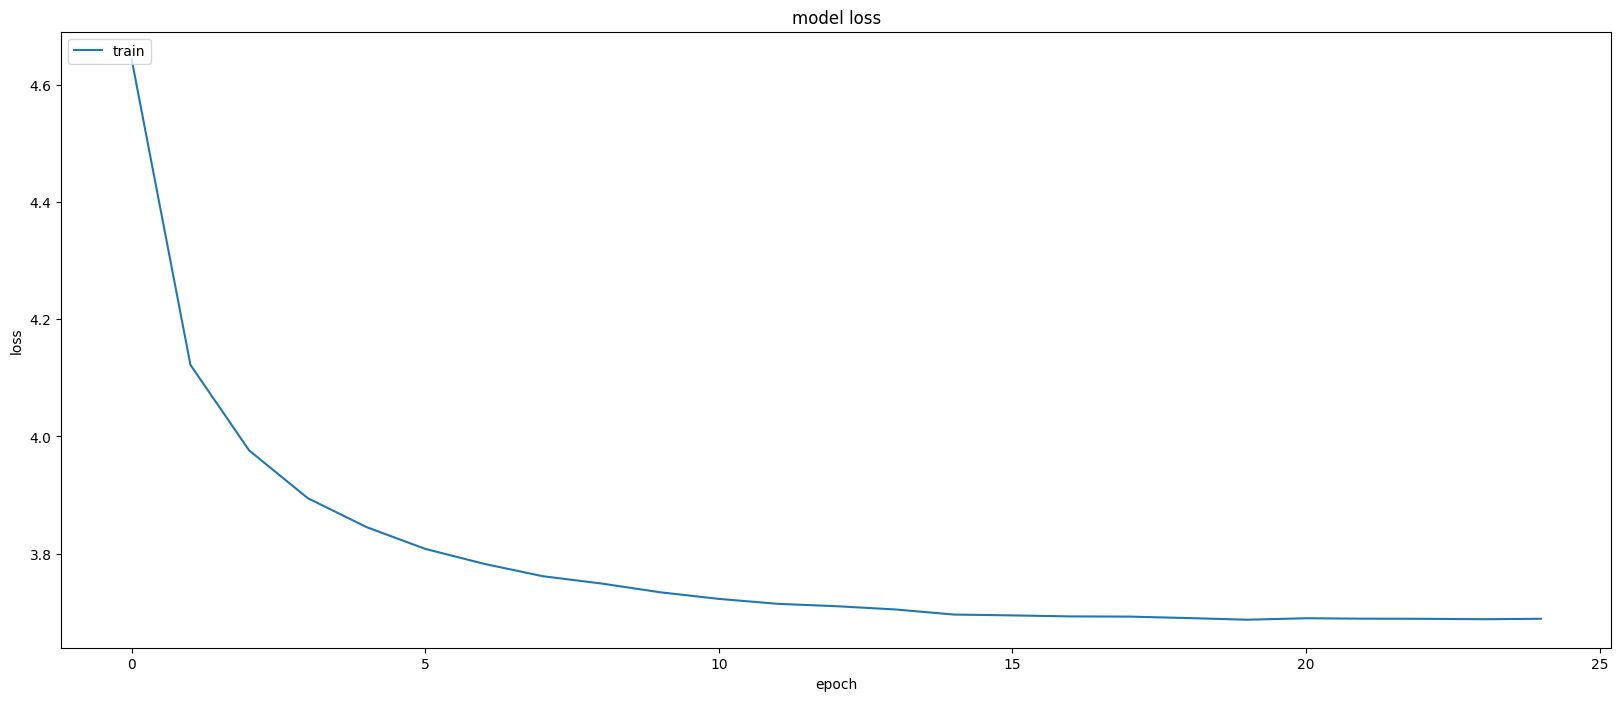

In [40]:
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [37]:
def idx_to_word(integer,tokenizer):
    
    for word, index in tokenizer.word_index.items():
        if index==integer:
            return word
    return None

def predict_caption(model, image, tokenizer, max_length, features):
    
    feature = features[image]
    in_text = "startseq"
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], max_length)

        y_pred = model.predict([feature,sequence])
        y_pred = np.argmax(y_pred)
        
        word = idx_to_word(y_pred, tokenizer)
        
        if word is None:
            break
            
        in_text+= " " + word
        
        if word == 'endseq':
            break
            
    return in_text 

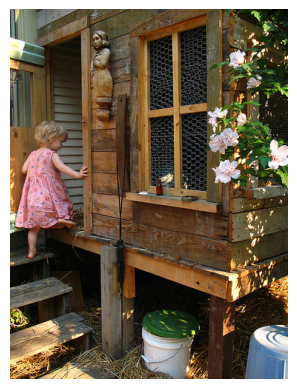

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Caption: startseq and people are standing on a bench endseq


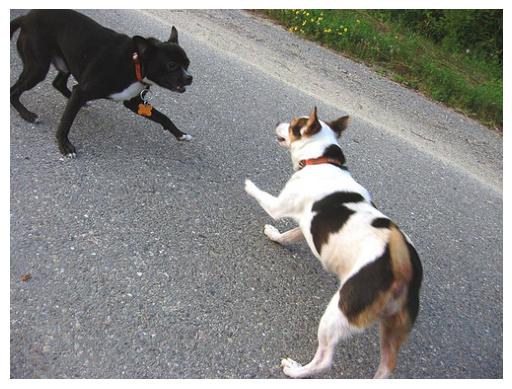

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Caption: startseq and people are standing on a bench endseq


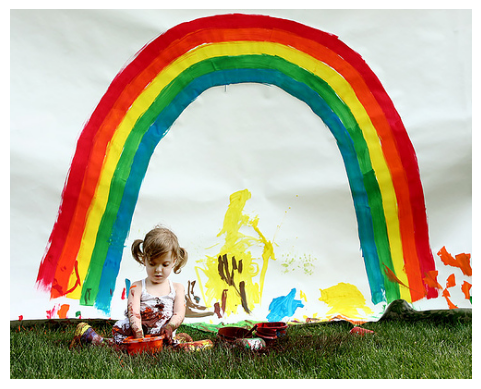

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Caption: startseq and people are standing on a bench endseq


In [39]:
samples = ['Flicker8k_Dataset/1000268201_693b08cb0e.jpg', 'Flicker8k_Dataset/1001773457_577c3a7d70.jpg', 'Flicker8k_Dataset/1002674143_1b742ab4b8.jpg']
for sample in samples:
    img = mpimg.imread(sample)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    img_id = os.path.basename(sample).split('.')[0]
    caption = predict_caption(model, img_id, tokenizer, maxLen, features)
    print(f"Predicted Caption: {caption}")
    
